### **Гипотеза:** Зная гендер испытуемого (0 — муж, 1 — жен), его гедоническую оценку запаха от -2 до +2 (далее Г.О.) и группу этого запаха, можно приблизтельно восстановить его активность головного мозга (в разбивке на 9 зон) на момент контакта с ним.

In [ ]:
from pathlib import Path
import collections
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
import numpy as np

from importer import *

In [23]:
PATH_ACTIVITY = Path('../DATA/activity/')
PATH_METAINFO = Path('../DATA/metainfo/name+type+ghedonic+gender.csv')
PATH_SPECTRAL = Path('../DATA/spectral/')

PATH_PROCDATA = Path('~hypothesis1-data')
CSV_PER_CAT = 2 # Изначально было 3, но 3-й по сути является шумом, его брать нет смысла

### 1. Конвертируем данные EEG-Cutter в нужный формат

In [24]:
subjects = Path.iterdir(PATH_ACTIVITY)

for subject in subjects:
    if subject.is_dir():
        files = list(filter(lambda f: str(f).endswith('.csv'), Path.iterdir(subject)))
        
        for file in files:
            if not (PATH_PROCDATA / subject.name / file.name).is_file():
                convert_eegc_activity(file, (PATH_PROCDATA / subject.name / file.name))

Визуальный обзор для нвглядности

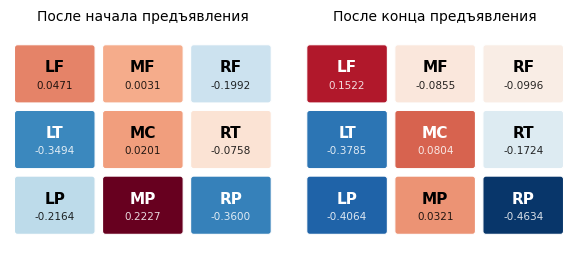

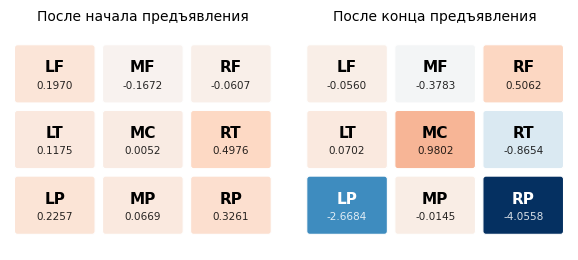

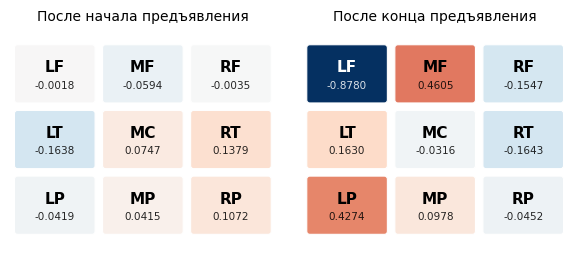

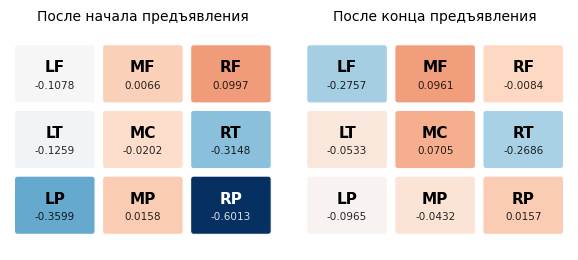

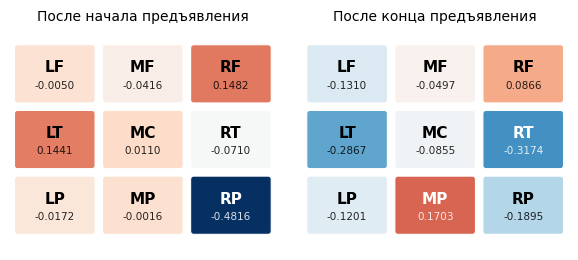

In [25]:
activites = list(Path.iterdir(PATH_PROCDATA / 'Bmet_007'))

for i in range(0, len(activites) - 2, CSV_PER_CAT):
    vis_acitivty_by_zones(
        read_zone_activations(activites[i]),
        read_zone_activations(activites[i+1]),
        'После начала предъявления',
        'После конца предъявления'
    )

### 2. Делаем агрегацию с названиями, Г.О., гендером

In [26]:
metainfo = pd.read_csv(PATH_METAINFO)

metainfo

,subject,trial,scent_name,scent_type,ghedonic,gender
0,Bmet_001,1,Ладан,Древесные,1,1
1,Bmet_001,2,Розмарин,Хвойные,-1,1
2,Bmet_001,3,Чайное дерево,Хвойные,1,1
3,Bmet_001,4,Нероли,Цветочные,-1,1
4,Bmet_001,5,Майоран,Травянистые / Гурманские,-2,1
...,...,...,...,...,...,...
109,Met_013,2,Сладкий апельсин,Цитрусовые,1,1
110,Met_013,3,Герань,Цветочные,0,1
111,Met_013,4,Бергамот,Цитрусовые,2,1
112,Met_013,5,Лаванда,Цветочные,1,1


Немного статистики!

In [27]:
metainfo['scent_name'].value_counts()

scent_name
Лаванда              11
Эвкалипт              9
Бергамот              8
Герань                6
Ладан                 6
Сандал                6
Дикий апельсин        5
Лимон                 5
Корица                5
Перечная мята         4
Розмарин              3
Мелисса               3
Римская ромашка       3
Апельсин              3
Сибирская пихта       2
Ветивер               2
Зелёный мандарин      2
Грейпфрут             2
Чёрный перец          2
Садовая мята          1
Шёпот                 1
Куркума               1
Нероли                1
Чайное дерево         1
Кардамон              1
Иланг-иланг           1
Баланс                1
Кассия                1
Майоран               1
Кипарис               1
Герань                1
Дугласова пихта       1
Цитрус блюс           1
Фенхель               1
Базилик               1
Мирт                  1
Грушанка              1
Шалфей                1
Лимонный эвкалипт     1
Красный мандарин      1
Мята                  1
Кедр 

In [28]:
counts = collections.Counter()

for t, c in metainfo['scent_type'].value_counts().items():
    ts = str(t).split('/')
    
    for s in ts:
        ss = s.strip()
        counts[ss] += c

type_c = pd.Series(counts)

type_c.sort_index()

Гурманские     15
Древесные      17
Землистые       2
Мятные          7
Травянистые    15
Хвойные        20
Цветочные      23
Цитрусовые     29
dtype: int64

In [29]:
list(type_c.keys())

['Цитрусовые',
 'Цветочные',
 'Хвойные',
 'Гурманские',
 'Древесные',
 'Травянистые',
 'Мятные',
 'Землистые']

In [30]:
genders = metainfo['gender'].value_counts()

print(f'{genders[1] / (genders[0] + genders[1]) * 100} % испытуемых -- женщины!')

72.80701754385966 % испытуемых -- женщины!


Вернёмся обратно к агрегации

In [31]:
# У меня нет Met_005, поэтому его дропаем:
metainfo.drop(metainfo[metainfo['subject'] == 'Met_005'].index, inplace=True)
metainfo.reset_index(drop=True, inplace=True)

metainfo['scent_type_split'] = metainfo['scent_type'].apply(
    lambda ts: [t.strip() for t in ts.split('/')]
)

mlb = MultiLabelBinarizer()
groups = mlb.fit_transform(metainfo['scent_type_split'])

groups_df = pd.DataFrame(groups, columns=mlb.classes_)

dataset_input = pd.concat([
    metainfo['gender'],
    metainfo['ghedonic'].apply(lambda g: (g + 3.0) / 5.0),
    groups_df
], axis=1).astype('float32')

dataset_input

,gender,ghedonic,Гурманские,Древесные,Землистые,Мятные,Травянистые,Хвойные,Цветочные,Цитрусовые
0,1.0,0.8,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
1,1.0,0.4,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2,1.0,0.8,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
3,1.0,0.4,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,1.0,0.2,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...
97,1.0,0.8,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
98,1.0,0.6,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
99,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
100,1.0,0.8,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [32]:
dataset_output_columns = []

for i in range(CSV_PER_CAT):
    for zn in ZONE_NAMES:
        dataset_output_columns.append(f'{zn}_{i}')

dataset_output = pd.DataFrame(columns=dataset_output_columns).astype('float32')

subjects = Path.iterdir(PATH_ACTIVITY)
iii = 0

for subject in sorted(subjects):
    if subject.is_dir():
        files = list(filter(lambda f: str(f).endswith('.csv'), Path.iterdir(subject)))
        
        for file in sorted(files):
            acts = convert_eegc_activity(file, (PATH_PROCDATA / subject.name / file.name))

            for k, v in acts.items():
                # if iii % CSV_PER_CAT != 0:
                #     break

                dataset_output.at[iii // CSV_PER_CAT, f'{k}_{iii % CSV_PER_CAT}'] = v

            iii += 1

# dataset_output = dataset_output[dataset_output.columns[dataset_output.columns.str.endswith('_0')]]
dataset_output

,LF_0,MF_0,RF_0,LT_0,MC_0,RT_0,LP_0,MP_0,RP_0,LF_1,MF_1,RF_1,LT_1,MC_1,RT_1,LP_1,MP_1,RP_1
0,0.261817,0.112693,0.083835,0.065102,-0.010713,0.057672,0.020023,-0.064081,0.106220,-0.395678,0.119252,-0.065677,-0.114105,0.009600,-0.010954,0.005693,0.064466,-0.034749
1,-0.119271,0.070146,-0.008217,-0.025100,0.032569,0.176896,-0.045746,-0.135861,-0.098791,-0.013958,-0.163316,0.020006,-0.014459,0.029677,-0.080352,-0.079463,0.078236,0.042223
2,0.145465,-0.016992,0.144319,0.103060,-0.041721,-0.085677,0.075078,-0.169137,0.115972,0.003939,-0.284964,-0.048582,0.017231,0.073191,0.083507,0.005698,0.039686,-0.031741
3,0.143122,-0.302455,0.054277,0.042155,-0.023253,0.039266,-0.026903,-0.460407,0.014547,0.244239,-0.163383,0.325244,-0.001412,-0.050756,0.060670,0.090715,-0.206584,-0.037430
4,0.355381,-0.143183,0.301232,0.191183,-0.163509,0.141477,0.065651,-0.058124,-0.016807,-0.458878,-0.110670,-0.020471,-0.088172,0.066996,0.020184,-0.005323,0.059746,-0.073671
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
97,0.107856,-0.055248,0.041547,0.025636,0.011800,0.154588,0.045740,0.090810,0.069729,-0.084558,-0.075963,0.385227,0.133797,0.023300,-0.314364,0.171825,-0.047818,-0.337446
98,-0.180564,-0.013691,-0.097953,-0.205180,-0.015786,-0.263400,-0.124468,-0.030703,-0.116371,0.392656,0.068956,-0.219675,-0.155154,-0.028106,0.618847,-0.204184,0.122998,-0.150142
99,0.149896,-0.068002,0.132906,-0.051669,0.006188,-0.324870,-0.196069,-0.096297,-0.269530,0.199472,0.004682,0.063670,0.023750,-0.073764,0.086235,-0.147799,0.069371,0.165414
100,0.031401,0.083411,-0.278035,-0.144576,0.137150,-0.285081,0.551076,0.131456,-0.937787,-0.326030,-0.031948,0.175198,0.231749,-0.077418,0.057107,0.179207,0.044985,-0.055963


In [33]:
dataset_output_mean = dataset_output.mean()
dataset_output_std = dataset_output.std()

# НОРМАЛИЗАЦИЯ
dataset_output_norm = (dataset_output - dataset_output_mean) / dataset_output_std

dataset_output_norm

,LF_0,MF_0,RF_0,LT_0,MC_0,RT_0,LP_0,MP_0,RP_0,LF_1,MF_1,RF_1,LT_1,MC_1,RT_1,LP_1,MP_1,RP_1
0,0.571155,0.968690,0.425810,0.257141,-0.201109,0.242965,0.167715,-0.445442,0.369334,-0.296404,1.366775,-0.426137,-0.278699,0.405932,-0.110267,0.150711,0.560868,-0.066001
1,-0.289525,0.633502,-0.160010,-0.270974,0.206095,0.743232,-0.044847,-1.141646,-0.085911,0.034474,-1.063856,-0.036713,-0.061385,0.761033,-0.302452,-0.257212,0.703154,0.145692
2,0.308376,-0.052983,0.810728,0.479379,-0.492827,-0.358530,0.345650,-1.464398,0.390991,0.049987,-2.110264,-0.348441,0.007726,1.530679,0.151325,0.150736,0.304802,-0.057726
3,0.303085,-2.301907,0.237700,0.122787,-0.319086,0.165730,0.016053,-4.289467,0.165766,0.258281,-1.064433,1.350558,-0.032931,-0.661606,0.088083,0.557992,-2.240062,-0.073372
4,0.782468,-1.047143,1.809322,0.995318,-1.638615,0.594614,0.315182,-0.387671,0.096142,-0.351186,-0.610996,-0.220678,-0.222143,1.421107,-0.024037,0.097941,0.512088,-0.173045
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
97,0.223437,-0.354374,0.156690,0.026073,0.010702,0.649627,0.250830,1.056864,0.288303,-0.026723,-0.312451,1.623177,0.261941,0.648240,-0.950502,0.946536,-0.599434,-0.898492
98,-0.427955,-0.026982,-0.731085,-1.325312,-0.248833,-1.104261,-0.299272,-0.121711,-0.124947,0.386930,0.934136,-1.126041,-0.368222,-0.260987,1.633844,-0.854667,1.165713,-0.383360
99,0.318384,-0.454853,0.738095,-0.426533,-0.042097,-1.362192,-0.530683,-0.757916,-0.465050,0.219477,0.381253,0.161736,0.021943,-1.068547,0.158880,-0.584564,0.611547,0.484497
100,0.050765,0.738007,-1.877125,-0.970484,1.189997,-1.195236,1.884052,1.451095,-1.948975,-0.236032,0.066164,0.668618,0.475560,-1.133185,0.078215,0.981899,0.359559,-0.124344


In [34]:
assert(len(dataset_input) == len(dataset_output_norm))

### 3. Пробуем обучить нейронную сеть

In [35]:
train_input, test_input, train_output, test_output = train_test_split(
    dataset_input, dataset_output_norm, test_size=0.33, random_state=666
)

In [36]:
train_input

,gender,ghedonic,Гурманские,Древесные,Землистые,Мятные,Травянистые,Хвойные,Цветочные,Цитрусовые
23,1.0,0.8,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
75,1.0,0.8,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
67,0.0,0.6,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0
50,1.0,0.6,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0
80,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...
70,0.0,0.8,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
62,0.0,0.6,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
30,1.0,0.6,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
45,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [37]:
test_input

,gender,ghedonic,Гурманские,Древесные,Землистые,Мятные,Травянистые,Хвойные,Цветочные,Цитрусовые
93,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
53,1.0,0.6,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
35,1.0,0.8,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0
37,0.0,0.8,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
43,0.0,0.8,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
6,1.0,0.8,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
17,1.0,0.8,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
72,0.0,0.6,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0
87,1.0,0.6,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
66,0.0,0.6,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0


In [38]:
train_input_t = torch.tensor(train_input.values, dtype=torch.float32)
train_output_t = torch.tensor(train_output.values, dtype=torch.float32)
test_input_t = torch.tensor(test_input.values, dtype=torch.float32)
test_output_t = torch.tensor(test_output.values, dtype=torch.float32)

Обойдёмся пока без изысков, обычная полносвязная модель:

In [39]:
class HypothesisModelV1(nn.Module):
    def __init__(self):
        super(HypothesisModelV1, self).__init__()

        self.fc1 = nn.Linear(10, 16) # = Гендер (1) + Г.О. (1) + Типы (8)
        self.do1 = nn.Dropout(0.2)
        self.fc2 = nn.Linear(16, 12)
        self.do2 = nn.Dropout(0.2)
        self.out = nn.Linear(12, dataset_output.shape[1]) # 9 зон по N кадров

    def forward(self, x):
        x = nn.functional.leaky_relu(self.fc1(x))
        x = self.do1(x)
        x = nn.functional.leaky_relu(self.fc2(x))
        x = self.do2(x)
        x = self.out(x)

        return x

In [40]:
model = HypothesisModelV1()
criterion = nn.MSELoss() 
optimizer = torch.optim.Adam(model.parameters(), lr=0.0002)

In [41]:
best_loss = 99.99
best_e = -1

for e in range(999999999):
    model.train()
    optimizer.zero_grad()
    
    train_pred = model(train_input_t)
    train_loss = criterion(train_pred, train_output_t)
    
    train_loss.backward()
    optimizer.step()

    model.eval()
    with torch.no_grad():
        test_pred = model(test_input_t)
        test_loss = criterion(test_pred, test_output_t)

        if test_loss.item() < best_loss:
            best_e = e
            best_loss = test_loss.item()

    if e % 200 == 0:
        print(f'Потери на train на эпохе {e} = {train_loss.item()}')
        print(f'Потери на test на эпохе {e} = {test_loss.item()}\n')

        if e - best_e >= 10000:
            print('Модель перестала учиться, this is the end...')
            print(f'Лучшая эпоха: {best_e} (потери на test: {best_loss})')
            break

Потери на train на эпохе 0 = 1.2829738855361938
Потери на test на эпохе 0 = 0.5291600823402405

Потери на train на эпохе 200 = 1.2414803504943848
Потери на test на эпохе 200 = 0.5092746615409851

Потери на train на эпохе 400 = 1.215491533279419
Потери на test на эпохе 400 = 0.5045299530029297

Потери на train на эпохе 600 = 1.2058500051498413
Потери на test на эпохе 600 = 0.5055672526359558

Потери на train на эпохе 800 = 1.181074857711792
Потери на test на эпохе 800 = 0.5118158459663391

Потери на train на эпохе 1000 = 1.1740597486495972
Потери на test на эпохе 1000 = 0.524879515171051

Потери на train на эпохе 1200 = 1.157213568687439
Потери на test на эпохе 1200 = 0.5372010469436646

Потери на train на эпохе 1400 = 1.1451354026794434
Потери на test на эпохе 1400 = 0.5484703183174133

Потери на train на эпохе 1600 = 1.15824556350708
Потери на test на эпохе 1600 = 0.5567059516906738

Потери на train на эпохе 1800 = 1.155540943145752
Потери на test на эпохе 1800 = 0.5641793012619019

П

\*смеющийся испанец мп4\*

In [42]:
model.eval()

with torch.no_grad():
    y_pred = model(test_input_t).numpy()
    y_true = test_output_t.numpy()

print(f"R2 Score: {r2_score(y_true, y_pred):.4f}")
print(f"MAE: {mean_absolute_error(y_true, y_pred):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_true, y_pred)):.4f}")

R2 Score: -0.7760
MAE: 0.5844
RMSE: 0.8306


### **Вывод:** на текущем объеме выборки сильные взаимосвязи не выявляются, а значит, модель лишь усиливает ошибку.

**В режиме одного кадра:**
- Лучшая эпоха: 260 (потери на test: 0.5377923250198364)
- R2 Score: -0.7098
- MAE: 0.5947
- RMSE: 0.8677

**В режиме двух кадров:**
- Лучшая эпоха: 465 (потери на test: 0.5041907429695129)
- R2 Score: -0.7760
- MAE: 0.5844
- RMSE: 0.8306